In [8]:
!pip install kaggle

In [9]:
import os
os.environ['KAGGLE_KEY'] = 'KGAT_d139e194503715d37b66cc181b37d023'
os.environ['KAGGLE_USERNAME'] = 'bhuvanatumma'

uploading kaggle api token to use data set

In [10]:
!kaggle datasets download -d uciml/human-activity-recognition-with-smartphones
!unzip human-activity-recognition-with-smartphones.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones
License(s): CC0-1.0
  0% 0.00/24.5M [00:00<?, ?B/s]
100% 24.5M/24.5M [00:00<00:00, 1.28GB/s]
Archive:  human-activity-recognition-with-smartphones.zip
  inflating: test.csv                
  inflating: train.csv               


getting the human activity data set, and unzippign the raw data file on website it has file w summary stats

sampling rate 50Hz (50 data points per second)

sliding window: chopped continuous movement into blocks of 2.56 seconds

overlap: each block shares 50% of its data with the next bloxk so no movement is cutoff in the middle

filtering: butterworth filter was used to seperate gravity (the earth pulling the phoen down) vs body motion

30 ppl total 21 in train 9 in test

sesnor data X (side to side), Y(up and down), Z (forward and backward)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
!ls -R

.:
human-activity-recognition-with-smartphones.zip  test.csv
sample_data					 train.csv

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


You're looking at `acc_x`, which is a `pandas.DataFrame` containing the 'body_acc_x' signal for the training set. Let's break down its structure:

*   **Rows**: Each row in the `acc_x` DataFrame represents a single **time window** (or segment) of 2.56 seconds. This window contains a sequence of accelerometer readings. So, if `acc_x.head()` shows 5 rows, it means it's displaying the first 5 such 2.56-second windows from the training data. The total number of rows in `acc_x` will be much larger, corresponding to all the 2.56-second windows extracted from the activities of all participants in the training set.

*   **Columns**: As you correctly noted, the sampling rate is 50 Hz (50 data points per second) and the window size is 2.56 seconds. Therefore, for each 2.56-second window, there are `50 samples/second * 2.56 seconds = 128 samples`. This is why the `acc_x` DataFrame has **128 columns**—each column represents a specific time step within that 2.56-second window.

*   **Total Time (2.56 x 5 rows)?**: No, the total time is not `2.56 x 5` seconds. The `head()` function only shows the first 5 rows for a quick preview. Each row is an independent 2.56-second segment. The entire `acc_x` DataFrame contains *many* such 2.56-second windows, stacked one after another, from all the activities recorded for the training participants.

*   **21 people in the training set**: This refers to the number of unique individuals whose accelerometer and gyroscope data were collected to form the training dataset. The rows in `acc_x` are derived from these 21 individuals. For instance, one row could be a 2.56-second window of data from 'Participant 1' performing 'Walking', and another row could be from 'Participant 15' performing 'Sitting'.

In essence, `acc_x` is a collection of these 2.56-second (128-sample) snapshots of body acceleration in the X-direction, taken from various activities performed by 21 different people.

In [13]:
#import pandas as pd
#acc_x = pd.read_csv('UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt', header=None, sep='\s+')


In [14]:
#print(f"The acc_x DataFrame has {acc_x.shape[0]} rows and {acc_x.shape[1]} columns.")

unzipping the raw data file that actually works

In [15]:
# 1. Download the original full dataset (includes raw signals)
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip

# 2. Unzip it
!unzip -q "UCI HAR Dataset.zip"

# 3. List the files again to verify
!ls "UCI HAR Dataset"

--2025-12-31 18:04:35--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [       <=>          ]  58.17M  43.5MB/s    in 1.3s    

2025-12-31 18:04:37 (43.5 MB/s) - ‘UCI HAR Dataset.zip’ saved [60999314]

activity_labels.txt  features_info.txt	features.txt  README.txt  test	train


In [16]:
acc_x = pd.read_csv(
    'UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt',
    sep='\s+', # Replaced delim_whitespace=True
    header=None
)
acc_x.head()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-87779339.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', # Replaced delim_whitespace=True


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.000181,0.010139,0.009276,0.005066,0.010810,0.004045,0.004757,0.006214,0.003307,0.007572,...,0.001412,-0.001509,0.000060,0.000435,-0.000819,0.000228,-0.000300,-0.001147,-0.000222,0.001576
1,0.001094,0.004550,0.002879,0.002247,0.003305,0.002416,0.001619,0.000981,0.000009,-0.000363,...,-0.000104,-0.000141,0.001333,0.001541,0.001077,-0.000736,-0.003767,-0.004646,-0.002941,-0.001599
2,0.003531,0.002285,-0.000420,-0.003738,-0.006706,-0.003148,0.000733,0.000668,0.002162,-0.000946,...,0.000661,0.001853,-0.000268,-0.000394,-0.000279,-0.000316,0.000144,0.001246,0.003117,0.002178
3,-0.001772,-0.001311,0.000388,0.000408,-0.000355,0.000998,0.001109,-0.003149,-0.008882,-0.010483,...,0.000458,0.002103,0.001358,0.000820,-0.000212,-0.001915,-0.001631,-0.000867,-0.001172,-0.000028
4,0.000087,-0.000272,0.001022,0.003126,0.002284,0.000885,0.001933,0.002270,0.002247,0.002175,...,0.002529,0.003518,-0.000248,-0.002761,0.000252,0.003752,0.001626,-0.000698,-0.001223,-0.003328


each row is one sensor window

getting the accelerometer (measures how fast **phone** is moving in a direction) data first

accessign the body_acc_x_train column so after butterworth filtering has been done your getting the body movement values in side to side direction (x)

128 individual readings taken at 50Hz

$50 \text{ readings per second} \times 2.56 \text{ seconds} \approx 128 \text{ readings}$

In [17]:
print(f"The acc_x DataFrame has {acc_x.shape[0]} rows and {acc_x.shape[1]} columns.")

The acc_x DataFrame has 7352 rows and 128 columns.


In [18]:
signal = acc_x.iloc[0].values
#only considering row 0, so only 128 values

fs = 50
# Hz frequency tellign python theres 50 snapshots per second

t = np.arange(len(signal)) / fs

#length of signal is 128 (columns)
#making the time axis for
#divides every number by 50, 0/50, 1/50 = 0.02s and so on for time axis


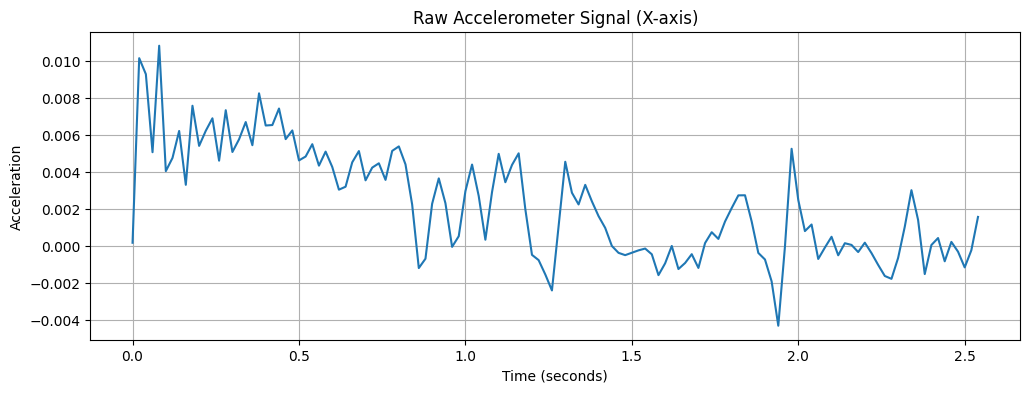

In [19]:
plt.figure(figsize=(12,4))
#12x4 canvas

plt.plot(t, signal)
#plot signal vs time

plt.title("Raw Accelerometer Signal (X-axis)")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration")

plt.grid(True)
#adds background grid

plt.show()


after lookign at this data we can tell that there is high frequency jitter (sensor noise) but at the same time there is low frequency osciallation (back and forth movement at regular speed)

we want to get rid of the high frequnecy jitter and keep the low frequnecy oscialltion (motion)

so we need to decide on a filtering strategy to do so

since walking is 1-2 Hz
      running is 2-4 Hz ish

so we decide on a cutoff at like maybe 5Hz

if movement repeats more than 5 times it probably not human motion and is noise

so we need to use LOW PASS FILTER (lets the low frequnecies pass through and blocks the high frequencies)

high passs is the oppostie

band pass blocks everythign below and above a certain point so u get the sweet spot

The Nyquist Shannon Theorem says you can only accurately measure frequencies up to half your sampling rate

ours sampling rate is 50Hz so we shall do 25 Hz

so so far we have found a dataset on kaggle embedded it into google colab through kaggle api token, and then has to retrieve the raw data by unzipping the file, and the understand what this raw data includes which was sensor data from to sensors scceleroemter and gyroscope which was in three directions X, Y, Z

and the freqqunecy at which the data was collected is 50 snapshots per seond (50Hz), and then we decided to start with just accelerometer data of the x - axis and just of the first window which is 2.56 seconds

rigth the data is in a matrix/table we want it as a time series so a graph to do that we need a time axis

and then visualize it as a graph

In [20]:
from scipy.signal import butter, filtfilt

# using filtfilt instead of lfilter

# lfilter causes phase shift "smears" the signal slightly to the right,
# meaning the peaks in your graph would happen
# a few milliseconds after they actually happened in real life

# using filtfilt runs the filter forward, then runs it backward over the data
# so

def lowpass_filter(data, cutoff, fs, order=4):
    #nyq therom
    nyq = 0.5 * fs

    #butter doesn't understand Hz so we divide our cutoff (5 Hz) by 25, you get 0.2
    # this tells us we want to keep 20% of the frequency and delte top 80%
    normal_cutoff = cutoff / nyq

    #butterworth filter recipie
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

filtered = lowpass_filter(signal, cutoff=5, fs=fs)


so we will implement low pass filter using the butterworth math, like how the code is written

there are other types of filters such as Chebyshev or Bessel

but for human movement we pick butterworth because most filters "wiggle" the data a little bit (called ripple) before they cut it off.

butterworth is known for being like maximally flat so were able to see the exact intensity of someoen walking

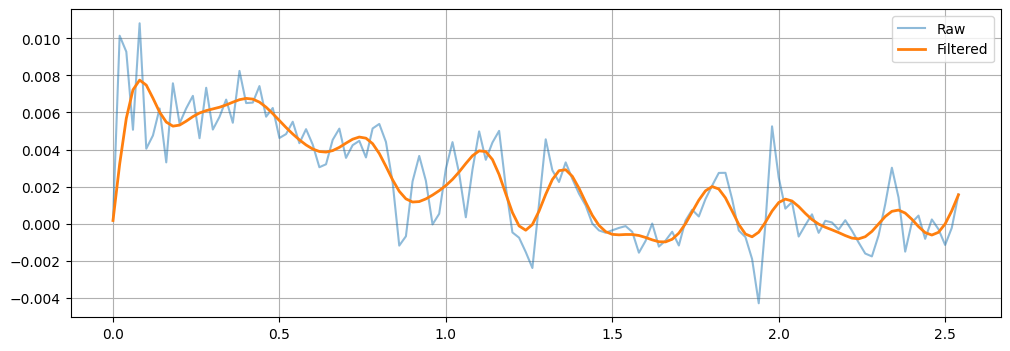

In [21]:
plt.figure(figsize=(12,4))
plt.plot(t, signal, label='Raw', alpha=0.5)
plt.plot(t, filtered, label='Filtered', linewidth=2)
plt.legend()
plt.grid(True)
plt.show()

now we compare the og data vs the filtered data because filter usually disorts signals a little so we must confirm that noise was reduced and motion preserved so we plot it

In [22]:
!ls -R

.:
 human-activity-recognition-with-smartphones.zip   train.csv
 __MACOSX					  'UCI HAR Dataset'
 sample_data					  'UCI HAR Dataset.zip'
 test.csv

./__MACOSX:
'UCI HAR Dataset'

'./__MACOSX/UCI HAR Dataset':
test  train

'./__MACOSX/UCI HAR Dataset/test':
'Inertial Signals'

'./__MACOSX/UCI HAR Dataset/test/Inertial Signals':

'./__MACOSX/UCI HAR Dataset/train':
'Inertial Signals'

'./__MACOSX/UCI HAR Dataset/train/Inertial Signals':

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md

'./UCI HAR Dataset':
activity_labels.txt  features_info.txt	features.txt  README.txt  test	train

'./UCI HAR Dataset/test':
'Inertial Signals'   subject_test.txt   X_test.txt   y_test.txt

'./UCI HAR Dataset/test/Inertial Signals':
body_acc_x_test.txt  body_gyro_x_test.txt  total_acc_x_test.txt
body_acc_y_test.txt  body_gyro_y_test.txt  total_acc_y_test.txt
body_acc_z_test.txt  body_gyro_z_test.txt  total_acc_z

we just used time-domain plots which aren't the most reliable so lets make use of frequency domain, because we've established that high frequency is noise and we don't want that in our analysis so in frequency domain all the high frequecny just sits to the right which can be easily cutoff

Frequency Domain Validation - FFT (Fast Fourier Transformation)

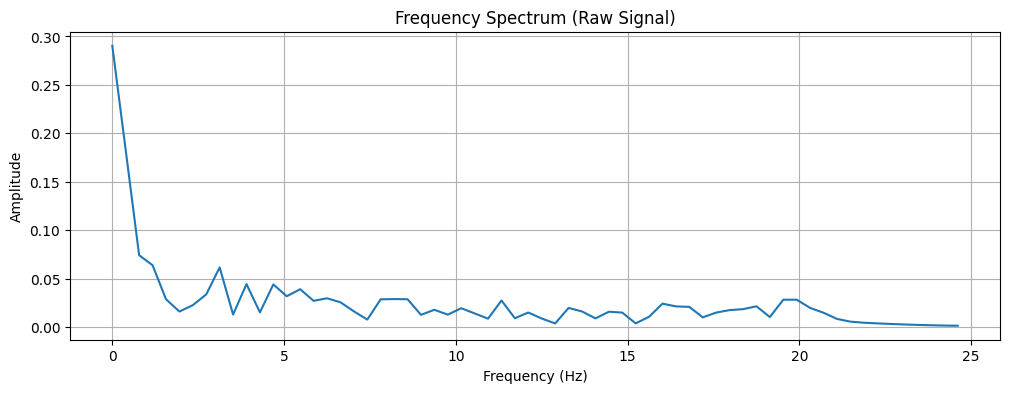

In [23]:
from scipy.fft import fft

N = len(signal)
#128

yf = fft(signal)
#takes the 128 samples and calculates the strength of every possible frequency
xf = np.fft.fftfreq(N, 1/fs)
#helper function from numpy sole purpose is to produce an array of frequencies based on FFT
#creates a list of frequencies in Hz, FFT can figure out amplitudes but not the x-axis values

plt.figure(figsize=(12,4))

plt.plot(xf[:N//2], np.abs(yf[:N//2]))
#FFT tends to create a mirror image the first half data 0 to 25 Hz is the real data
#the later half till 50 Hz isnt required so it can be cutoff

plt.title("Frequency Spectrum (Raw Signal)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

3Hz we see a peak so that means the walking (experiemntal data) is there and its jittery towards the end so noise still exists

1. Why use a Low-Pass Filter?
Think of your sensor data like a voice recording in a noisy room. The "Low-Pass" filter is like a noise-canceling headphone. It lets the deep, low sounds (the person's voice/body movement) through, but blocks out the high-pitched "hiss" and static (electronic jitter).

2. Why is the "Cutoff" set to 5 Hz?
This is based on human physics.

Humans are heavy and move relatively slowly.

We walk at about 2 steps per second (2 Hz) and run at about 4 steps per second (4 Hz).

By cutting everything above 5 Hz, you keep the person’s movement but throw away anything "too fast" to be a human, like the phone vibrating in a pocket.

3. Why Butterworth instead of a "Moving Average"?
Moving Average is like using a blurry lens; it smooths the noise but also makes the important peaks blurry.

Butterworth is like a surgical tool. It keeps the "Walking" waves perfectly sharp and accurate while cleanly removing the garbage. It’s "cleaner" math that doesn't lag or distort the timing of the steps.

4. How does the FFT prove you’re right?
The FFT is like a prism that breaks light into a rainbow. It breaks your messy wave into a "rainbow" of speeds:

On your graph, you saw a big bump around 2-3 Hz—that’s your proof that the "Walking" signal is actually there.

You saw "messy grass" at the high end—that’s your proof that noise exists.

The FFT validates your design because it shows you exactly where the "good stuff" ends and the "bad stuff" begins.

so far we've only convered one axis of the accelerometer we need to get the other 2 as well Y and Z

so lets get the raw data first

In [24]:
acc_y = pd.read_csv(
    'UCI HAR Dataset/train/Inertial Signals/body_acc_y_train.txt',
    delim_whitespace=True,
    header=None
)

acc_z = pd.read_csv(
    'UCI HAR Dataset/train/Inertial Signals/body_acc_z_train.txt',
    delim_whitespace=True,
    header=None
)

/tmp/ipython-input-1466470994.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  acc_y = pd.read_csv(
/tmp/ipython-input-1466470994.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  acc_z = pd.read_csv(


so far with x-axis data:

The Sensor: Records everything from 0 to 25 Hz. (Anything higher is physically lost).

The FFT Plot: Shows you the whole 0 to 25 Hz range so you can see the mess.

The Butterworth Filter: You "chop" the signal at 5 Hz.

The Result: You now have a clean signal that only contains the 0 to 5 Hz "diamonds" and has tossed out the 5 to 25 Hz "sand."

In [25]:
signal_x = acc_x.iloc[0].values
signal_y = acc_y.iloc[0].values
signal_z = acc_z.iloc[0].values

#getting the first row, the 128 samples for each axis

In [26]:
fx = lowpass_filter(signal_x, cutoff=5, fs=fs)
fy = lowpass_filter(signal_y, cutoff=5, fs=fs)
fz = lowpass_filter(signal_z, cutoff=5, fs=fs)
#lowpass_filter the butterworth filter fucntion we defined earlier

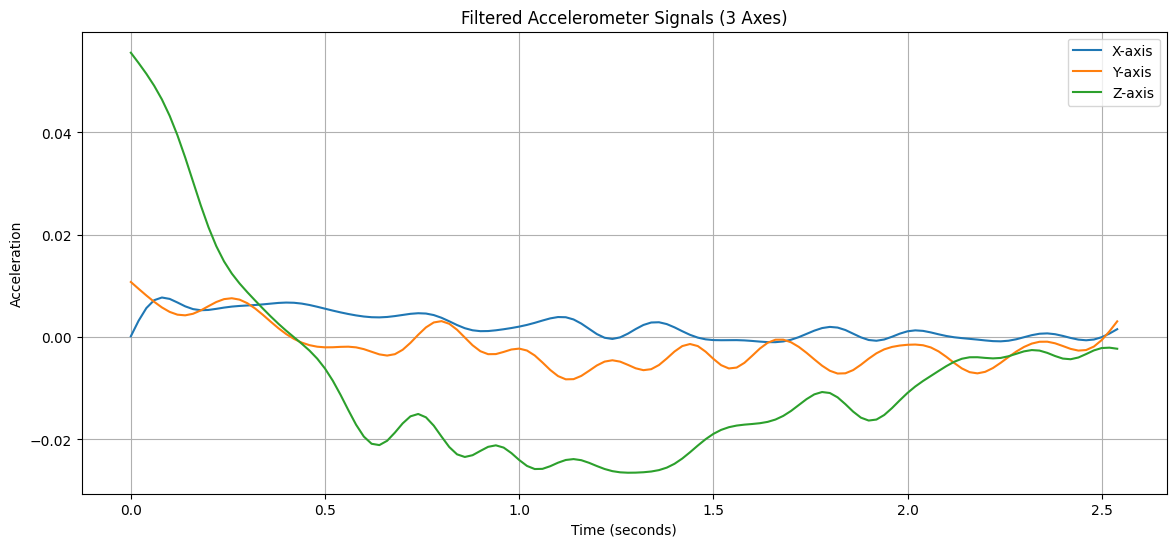

In [27]:
plt.figure(figsize=(14,6))

plt.plot(t, fx, label='X-axis')
plt.plot(t, fy, label='Y-axis')
plt.plot(t, fz, label='Z-axis')

plt.title("Filtered Accelerometer Signals (3 Axes)")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration")
plt.legend()
plt.grid(True)
plt.show()
#visualize all 3 axes

next we need to find the magnitude (tells us the strength or size of something always a postive value from 0)

In [28]:
magnitude = np.sqrt(fx**2 + fy**2 + fz**2)
#magnitude equation squareroot of the sum of square inputs

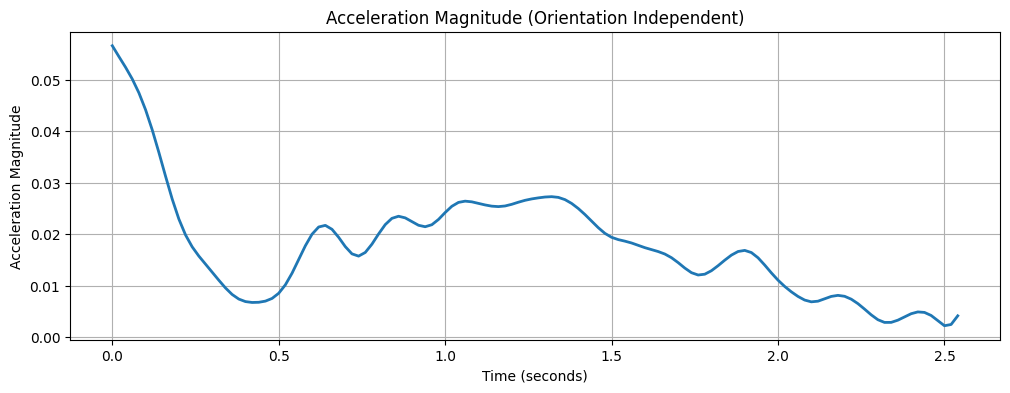

In [29]:
plt.figure(figsize=(12,4))
plt.plot(t, magnitude, linewidth=2)
plt.title("Acceleration Magnitude (Orientation Independent)")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration Magnitude")
plt.grid(True)
plt.show()

#visualize the magnitude
#helps us measure the intensity of the event not the direction, combing the three axes/directions into one

everything in realife happens in 3d so we need all three axes to determien motion

if we only consider one axis, so the sensor only looks at side by side that results in a lot of blindspots

we're meausring the intensity of the event and not the direction, as magnitude will stay the same no matter which direction the phone is tilted

you need to filter the data get rid of the high frequeny values first before combining the together with magnitude

robustness of a device is how accurate it is in unpredictable, noisy or messy environments

so to imporve robustness we are:

Filtering: Removes the "garbage" (noise) so it doesn't mess up your math.

FFT: Digs through the remaining signal to find the exact frequency you are looking for, ignoring everything else.

Magnitude: Ensures the signal stays the same even if the sensor is tilted.



In [30]:
signal = magnitude

mean_val = np.mean(signal)
# sitting/laying will be near 0
# walking will be non-zero
# so mean will help us differentiate this

variance_val = np.var(signal)
# static activities very low variance
# dynamic activites high variance

energy_val = np.sum(signal ** 2) / len(signal)
# signal energy equation encodes total movement
# low sitting down, layinh
# high walking, upstairs, downstairs

from scipy.signal import find_peaks

peaks, _ = find_peaks(signal, distance=fs*0.3)
peak_count = len(peaks)
# walking would entail multiple peaks
#sitting would be zero peaks

features = {
    "mean": mean_val,
    "variance": variance_val,
    "energy": energy_val,
    "peak_count": peak_count
}

features


{'mean': np.float64(0.01775950354790199),
 'variance': np.float64(0.00011873223908122381),
 'energy': np.float64(0.0004341322053491672),
 'peak_count': 4}

In [31]:
import pandas as pd

# Activity labels for training windows
y_train = pd.read_csv(
    'UCI HAR Dataset/train/y_train.txt',
    header=None,
    names=['Activity']
)

# Optional: map numeric labels to text
activity_map = {
    1: "Walking",
    2: "Walking_Upstairs",
    3: "Walking_Downstairs",
    4: "Sitting",
    5: "Standing",
    6: "Laying"
}

y_train['Activity_Name'] = y_train['Activity'].map(activity_map)


In [32]:
import numpy as np
from scipy.signal import find_peaks

# Load all accelerometer axes
acc_x = pd.read_csv('UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt', delim_whitespace=True, header=None)
acc_y = pd.read_csv('UCI HAR Dataset/train/Inertial Signals/body_acc_y_train.txt', delim_whitespace=True, header=None)
acc_z = pd.read_csv('UCI HAR Dataset/train/Inertial Signals/body_acc_z_train.txt', delim_whitespace=True, header=None)

fs = 50  # sampling frequency

def lowpass_filter(signal, cutoff=5, fs=50, order=4):
    from scipy.signal import butter, filtfilt
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

features_list = []

for i in range(len(acc_x)):
    # Extract window signals
    x = lowpass_filter(acc_x.iloc[i].values)
    y = lowpass_filter(acc_y.iloc[i].values)
    z = lowpass_filter(acc_z.iloc[i].values)

    # Compute magnitude
    mag = np.sqrt(x**2 + y**2 + z**2)

    # Compute features
    mean_val = np.mean(mag)
    var_val = np.var(mag)
    energy_val = np.sum(mag**2)/len(mag)
    peaks, _ = find_peaks(mag, distance=fs*0.3)
    peak_count = len(peaks)

    features_list.append([mean_val, var_val, energy_val, peak_count])

# Convert to DataFrame
X_train = pd.DataFrame(features_list, columns=['Mean','Variance','Energy','PeakCount'])


/tmp/ipython-input-3719095026.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  acc_x = pd.read_csv('UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt', delim_whitespace=True, header=None)
/tmp/ipython-input-3719095026.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  acc_y = pd.read_csv('UCI HAR Dataset/train/Inertial Signals/body_acc_y_train.txt', delim_whitespace=True, header=None)
/tmp/ipython-input-3719095026.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  acc_z = pd.read_csv('UCI HAR Dataset/train/Inertial Signals/body_acc_z_train.txt', delim_whitespace=True, header=None)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Split train/test for validation
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train['Activity'], test_size=0.2, random_state=42)

# Train
clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_tr)

# Predict
y_pred = clf.predict(X_val)

# Evaluate
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, target_names=[activity_map[i] for i in range(1,7)]))


Accuracy: 0.4697484704282801
                    precision    recall  f1-score   support

           Walking       0.64      0.86      0.73       247
  Walking_Upstairs       0.51      0.36      0.42       200
Walking_Downstairs       0.77      0.69      0.73       206
           Sitting       0.00      0.00      0.00       262
          Standing       0.31      0.51      0.39       276
            Laying       0.34      0.44      0.38       280

          accuracy                           0.47      1471
         macro avg       0.43      0.48      0.44      1471
      weighted avg       0.41      0.47      0.43      1471



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


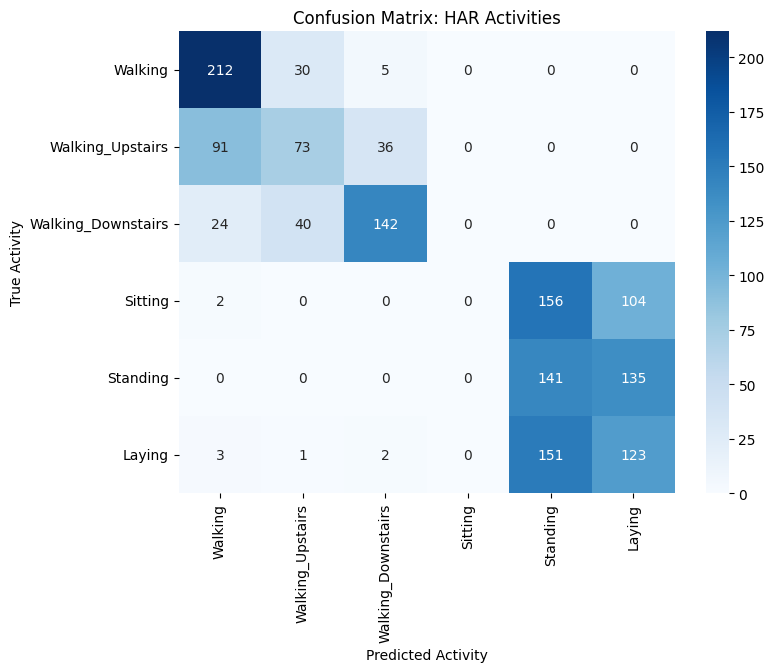

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[activity_map[i] for i in range(1,7)],
            yticklabels=[activity_map[i] for i in range(1,7)])
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.title("Confusion Matrix: HAR Activities")
plt.show()


In [35]:
coef = clf.coef_
features = ['Mean','Variance','Energy','PeakCount']

for i, activity in enumerate(activity_map.values()):
    print(f"Activity: {activity}")
    for f, c in zip(features, coef[i]):
        print(f"  {f}: {c:.3f}")
    print()


Activity: Walking
  Mean: 9.358
  Variance: -2.707
  Energy: -5.777
  PeakCount: 0.449

Activity: Walking_Upstairs
  Mean: 11.338
  Variance: -1.217
  Energy: 2.119
  PeakCount: 0.244

Activity: Walking_Downstairs
  Mean: 12.877
  Variance: 4.651
  Energy: 12.562
  PeakCount: -0.067

Activity: Sitting
  Mean: -11.472
  Variance: -0.201
  Energy: -3.238
  PeakCount: -0.193

Activity: Standing
  Mean: -11.588
  Variance: -0.597
  Energy: -3.949
  PeakCount: -0.166

Activity: Laying
  Mean: -10.514
  Variance: 0.072
  Energy: -1.717
  PeakCount: -0.267



In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

pipe_lr.fit(X_tr, y_tr)
y_pred_scaled = pipe_lr.predict(X_val)

from sklearn.metrics import accuracy_score
print("Scaled LR Accuracy:", accuracy_score(y_val, y_pred_scaled))


Scaled LR Accuracy: 0.5295717199184229


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_tr, y_tr)
y_pred_rf = rf.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))


Random Forest Accuracy: 0.5635622025832767


In [38]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importance


,0
Variance,0.355017
Mean,0.336258
Energy,0.276851
PeakCount,0.031874


# Task
Load the test accelerometer data from `UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt`, `UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt`, and `UCI HAR Dataset/test/Inertial Signals/body_acc_z_test.txt`, and load the activity labels from `UCI HAR Dataset/test/y_test.txt`. Then, map the numeric activity labels to their descriptive names using the `activity_map` variable defined previously.

## Load Test Data

### Subtask:
Load the accelerometer data (`body_acc_x_test.txt`, `body_acc_y_test.txt`, `body_acc_z_test.txt`) and activity labels (`y_test.txt`) for the test set into pandas DataFrames. Also, map the numeric activity labels to their descriptive names using the existing `activity_map`.


**Reasoning**:
Loading the test set accelerometer data for x, y, and z axes, and the activity labels into pandas DataFrames. Then, I will map the numeric activity labels to their descriptive names using the predefined 'activity_map'.



In [39]:
def load_signal(file_path):
    return np.loadtxt(file_path)


In [40]:
# Accelerometer
acc_x_train = load_signal("UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt")
acc_y_train = load_signal("UCI HAR Dataset/train/Inertial Signals/body_acc_y_train.txt")
acc_z_train = load_signal("UCI HAR Dataset/train/Inertial Signals/body_acc_z_train.txt")

acc_x_test = load_signal("UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt")
acc_y_test = load_signal("UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt")
acc_z_test = load_signal("UCI HAR Dataset/test/Inertial Signals/body_acc_z_test.txt")

# Gyroscope
gyro_x_train = load_signal("UCI HAR Dataset/train/Inertial Signals/body_gyro_x_train.txt")
gyro_y_train = load_signal("UCI HAR Dataset/train/Inertial Signals/body_gyro_y_train.txt")
gyro_z_train = load_signal("UCI HAR Dataset/train/Inertial Signals/body_gyro_z_train.txt")

gyro_x_test = load_signal("UCI HAR Dataset/test/Inertial Signals/body_gyro_x_test.txt")
gyro_y_test = load_signal("UCI HAR Dataset/test/Inertial Signals/body_gyro_y_test.txt")
gyro_z_test = load_signal("UCI HAR Dataset/test/Inertial Signals/body_gyro_z_test.txt")

In [41]:
def extract_features_from_window(window):
    mean = np.mean(window)
    var = np.var(window)
    energy = np.sum(window**2) / len(window)
    peaks, _ = find_peaks(window, height=0.5)
    return [mean, var, energy, len(peaks)]

In [42]:
def build_features(acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z):
    feature_matrix = []

    for i in range(len(acc_x)):  # each window
        features = []

        # Accelerometer axes
        features += extract_features_from_window(acc_x[i])
        features += extract_features_from_window(acc_y[i])
        features += extract_features_from_window(acc_z[i])

        # Gyroscope axes
        features += extract_features_from_window(gyro_x[i])
        features += extract_features_from_window(gyro_y[i])
        features += extract_features_from_window(gyro_z[i])

        feature_matrix.append(features)

    return np.array(feature_matrix)

In [43]:
def build_features(acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z):
    feature_matrix = []

    for i in range(len(acc_x)):  # each window
        features = []

        # Accelerometer axes
        features += extract_features_from_window(acc_x[i])
        features += extract_features_from_window(acc_y[i])
        features += extract_features_from_window(acc_z[i])

        # Gyroscope axes
        features += extract_features_from_window(gyro_x[i])
        features += extract_features_from_window(gyro_y[i])
        features += extract_features_from_window(gyro_z[i])

        feature_matrix.append(features)

    return np.array(feature_matrix)


In [44]:
# Build accelerometer-only features
X_train_acc = build_features(
    acc_x_train, acc_y_train, acc_z_train,
    np.zeros_like(acc_x_train),  # no gyro
    np.zeros_like(acc_x_train),
    np.zeros_like(acc_x_train)
)

X_test_acc = build_features(
    acc_x_test, acc_y_test, acc_z_test,
    np.zeros_like(acc_x_test),
    np.zeros_like(acc_x_test),
    np.zeros_like(acc_x_test)
)


In [45]:
# Define y_train_labels from the existing y_train DataFrame
y_train_labels = y_train['Activity']

# Load test activity labels
y_test_df = pd.read_csv(
    'UCI HAR Dataset/test/y_test.txt',
    header=None,
    names=['Activity']
)

# Map numeric labels to text for test set
y_test_df['Activity_Name'] = y_test_df['Activity'].map(activity_map)
y_test_labels = y_test_df['Activity']

clf_acc = LogisticRegression(max_iter=1000)
clf_acc.fit(X_train_acc, y_train_labels)

y_pred_acc = clf_acc.predict(X_test_acc)

print("Accel-only accuracy:", accuracy_score(y_test_labels, y_pred_acc))
print(classification_report(
    y_test_labels, y_pred_acc,
    target_names=[activity_map[i] for i in range(1, 7)]
))


Accel-only accuracy: 0.4509670851713607
                    precision    recall  f1-score   support

           Walking       0.45      0.45      0.45       496
  Walking_Upstairs       0.58      0.34      0.43       471
Walking_Downstairs       0.78      0.76      0.77       420
           Sitting       0.60      0.02      0.04       491
          Standing       0.43      0.37      0.40       532
            Laying       0.33      0.79      0.46       537

          accuracy                           0.45      2947
         macro avg       0.53      0.45      0.42      2947
      weighted avg       0.52      0.45      0.42      2947



In [46]:
# Build fused features (Accelerometer + Gyroscope)
X_train_feat = build_features(
    acc_x_train, acc_y_train, acc_z_train,
    gyro_x_train, gyro_y_train, gyro_z_train
)

X_test_feat = build_features(
    acc_x_test, acc_y_test, acc_z_test,
    gyro_x_test, gyro_y_test, gyro_z_test
)

clf_fused = LogisticRegression(max_iter=1000)
clf_fused.fit(X_train_feat, y_train_labels)

y_pred_fused = clf_fused.predict(X_test_feat)

print("Accel + Gyro accuracy:", accuracy_score(y_test_labels, y_pred_fused))
print(classification_report(
    y_test_labels, y_pred_fused,
    target_names=[activity_map[i] for i in range(1, 7)]
))

Accel + Gyro accuracy: 0.5174753987105531
                    precision    recall  f1-score   support

           Walking       0.71      0.76      0.73       496
  Walking_Upstairs       0.69      0.72      0.70       471
Walking_Downstairs       0.87      0.73      0.79       420
           Sitting       0.38      0.12      0.19       491
          Standing       0.32      0.61      0.42       532
            Laying       0.31      0.23      0.26       537

          accuracy                           0.52      2947
         macro avg       0.55      0.53      0.52      2947
      weighted avg       0.53      0.52      0.50      2947



In [47]:
from sklearn.metrics import confusion_matrix

cm_acc = confusion_matrix(y_test_labels, y_pred_acc)
cm_fused = confusion_matrix(y_test_labels, y_pred_fused)

print("Accel-only Confusion Matrix:\n", cm_acc)
print("\nAccel + Gyro Confusion Matrix:\n", cm_fused)


Accel-only Confusion Matrix:
 [[221  59  47   1   3 165]
 [228 161  41   1   3  37]
 [ 41  58 318   0   0   3]
 [  0   0   0   9 142 340]
 [  0   0   0   3 197 332]
 [  0   0   0   1 113 423]]

Accel + Gyro Confusion Matrix:
 [[376  71  26   0  19   4]
 [114 337  18   1   1   0]
 [ 36  75 306   2   0   1]
 [  0   2   0  60 286 143]
 [  5   3   0  71 323 130]
 [  1   0   0  23 390 123]]


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Train the classifier on TRAIN data
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_feat, y_train_labels)

LogisticRegression(max_iter=1000)

Test Accuracy: 0.517


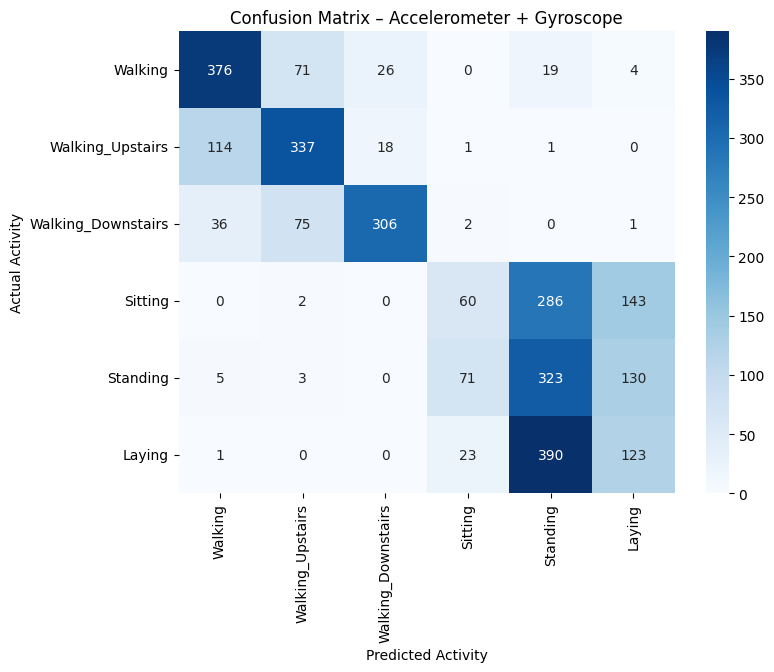

In [49]:
# Predict on TEST data (unseen data)
y_pred = clf.predict(X_test_feat)

# Compute accuracy
acc = accuracy_score(y_test_labels, y_pred)
print(f"Test Accuracy: {acc:.3f}")

cm = confusion_matrix(y_test_labels, y_pred)

activity_labels = [
    "Walking",
    "Walking_Upstairs",
    "Walking_Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,            # show numbers
    fmt="d",               # integer formatting
    cmap="Blues",          # color theme
    xticklabels=activity_labels,
    yticklabels=activity_labels
)

plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.title("Confusion Matrix – Accelerometer + Gyroscope")
plt.show()


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train_labels)

y_pred_rf = rf.predict(X_test_scaled)

print("Accel + Gyro RF Accuracy:",
      accuracy_score(y_test_labels, y_pred_rf))


Accel + Gyro RF Accuracy: 0.8215134034611469


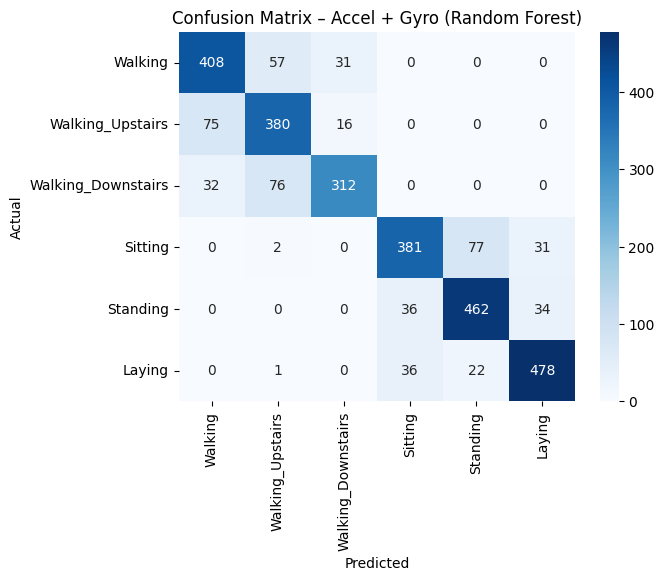

In [52]:
cm_rf = confusion_matrix(y_test_labels, y_pred_rf)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_labels,
    yticklabels=activity_labels
)

plt.title("Confusion Matrix – Accel + Gyro (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [53]:
import pandas as pd
import numpy as np

# Define feature names for accelerometer data
accel_feature_names = [
    'Mean_acc_x', 'Variance_acc_x', 'Energy_acc_x', 'PeakCount_acc_x',
    'Mean_acc_y', 'Variance_acc_y', 'Energy_acc_y', 'PeakCount_acc_y',
    'Mean_acc_z', 'Variance_acc_z', 'Energy_acc_z', 'PeakCount_acc_z'
]

# Define feature names for gyroscope data
gyro_feature_names = [
    'Mean_gyro_x', 'Variance_gyro_x', 'Energy_gyro_x', 'PeakCount_gyro_x',
    'Mean_gyro_y', 'Variance_gyro_y', 'Energy_gyro_y', 'PeakCount_gyro_y',
    'Mean_gyro_z', 'Variance_gyro_z', 'Energy_gyro_z', 'PeakCount_gyro_z'
]

feature_names = (
    accel_feature_names +
    gyro_feature_names
)

importances = rf.feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(imp_df.head(10))


            Feature  Importance
2      Energy_acc_x    0.121829
1    Variance_acc_x    0.121665
13  Variance_gyro_x    0.075224
14    Energy_gyro_x    0.062664
21  Variance_gyro_z    0.058422
17  Variance_gyro_y    0.052451
12      Mean_gyro_x    0.048916
5    Variance_acc_y    0.046971
20      Mean_gyro_z    0.043875
22    Energy_gyro_z    0.042824


In [54]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train_scaled, y_train_labels)

y_pred_svm = svm.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test_labels, y_pred_svm))


SVM Accuracy: 0.6043434000678656
